In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
import scanpy as sc
import anndata as ad

## Bulk RNA seq data processing and AnnData obj creation

### Loading in bulk RNA Seq data

In [2]:

bulk_seq = pd.read_csv("/Users/marikaclark/Downloads/GSE193141_rna_counts_011622.csv")
bulk_seq.head()

,Geneid,GeneSymbol,RNA_CR_027,RNA_CR_028,RNA_CR_029,RNA_CR_030,RNA_CR_031,RNA_CR_032,RNA_CR_034,RNA_CR_035,...,RNA_CR_177,RNA_CR_178,RNA_CR_179,RNA_CR_180,RNA_CR_181,RNA_CR_182,RNA_CR_183,RNA_CR_184,RNA_CR_185,RNA_CR_186
0,ENSG00000284662,OR4F3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,ENSG00000186827,TNFRSF4,1554,282,436,546,253,460,482,128,...,411,509,303,44,329,589,811,258,1920,1353
2,ENSG00000186891,TNFRSF18,1895,332,885,887,244,710,646,233,...,419,842,510,30,493,808,1138,378,1060,1674
3,ENSG00000160072,ATAD3B,3241,1509,2454,2401,3082,2891,2077,2006,...,2555,2229,2612,177,2605,2775,3331,3458,3768,3887
4,ENSG00000041988,THAP3,432,286,412,405,447,405,321,284,...,412,412,424,200,503,432,607,562,660,644


### Loading Demographic data

In [4]:
target_lines = {25, 26, 35, 36} | set(range(42, 52))
    #| acting as the union symbol 
metadata_rows = []

with open("/Users/marikaclark/dark_matter_atx/data/Morandini_2024/Bulk data/GSE193142_series_matrix (1).txt") as f:
    for i, line in enumerate(f):
        # print(f"Line {i:3d}: {line}")  # first 120 chars of each line
        if i>51: 
            break 

        if i in target_lines: 
            clean_line = line.strip()
            if clean_line: 
                tokens = clean_line.split("\t")
                    #splitting tab-delimited into row list
                metadata_rows.append(tokens)
df_metadata = pd.DataFrame(metadata_rows)

df_processes = df_metadata.iloc[4:, 0:2]
df_metadata
    #.iloc necessary for slicing two dimensions at same time 

,0,1,2,3,4,5,6,7,8,9,...,307,308,309,310,311,312,313,314,315,316
0,!Sample_title,"""ATAC_CR_027""","""ATAC_CR_028""","""ATAC_CR_029""","""ATAC_CR_030""","""ATAC_CR_031""","""ATAC_CR_032""","""ATAC_CR_034""","""ATAC_CR_035""","""ATAC_CR_036""",...,"""RNA_CR_177""","""RNA_CR_178""","""RNA_CR_179""","""RNA_CR_180""","""RNA_CR_181""","""RNA_CR_182""","""RNA_CR_183""","""RNA_CR_184""","""RNA_CR_185""","""RNA_CR_186"""
1,!Sample_geo_accession,"""GSM5774299""","""GSM5774300""","""GSM5774301""","""GSM5774302""","""GSM5774303""","""GSM5774304""","""GSM5774305""","""GSM5774306""","""GSM5774307""",...,"""GSM6102436""","""GSM6102437""","""GSM6102438""","""GSM6102439""","""GSM6102440""","""GSM6102441""","""GSM6102442""","""GSM6102443""","""GSM6102444""","""GSM6102445"""
2,!Sample_characteristics_ch1,"""age: 22""","""age: 64""","""age: 58""","""age: 61""","""age: 42""","""age: 45""","""age: 46""","""age: 70""","""age: 66""",...,"""age: 31""","""age: 62""","""age: 31""","""age: 65""","""age: 48""","""age: 51""","""age: 30""","""age: 45""","""age: 54""","""age: 44"""
3,!Sample_characteristics_ch1,"""gender: F""","""gender: M""","""gender: F""","""gender: M""","""gender: F""","""gender: M""","""gender: F""","""gender: M""","""gender: F""",...,"""gender: M""","""gender: M""","""gender: M""","""gender: M""","""gender: M""","""gender: M""","""gender: M""","""gender: M""","""gender: M""","""gender: F"""
4,!Sample_data_processing,"""Adapter trimming: Trim Galore! version 0.6.6 ...","""Adapter trimming: Trim Galore! version 0.6.6 ...","""Adapter trimming: Trim Galore! version 0.6.6 ...","""Adapter trimming: Trim Galore! version 0.6.6 ...","""Adapter trimming: Trim Galore! version 0.6.6 ...","""Adapter trimming: Trim Galore! version 0.6.6 ...","""Adapter trimming: Trim Galore! version 0.6.6 ...","""Adapter trimming: Trim Galore! version 0.6.6 ...","""Adapter trimming: Trim Galore! version 0.6.6 ...",...,"""Alignment: STAR aligner (v2.7.9a) with '--sjd...","""Alignment: STAR aligner (v2.7.9a) with '--sjd...","""Alignment: STAR aligner (v2.7.9a) with '--sjd...","""Alignment: STAR aligner (v2.7.9a) with '--sjd...","""Alignment: STAR aligner (v2.7.9a) with '--sjd...","""Alignment: STAR aligner (v2.7.9a) with '--sjd...","""Alignment: STAR aligner (v2.7.9a) with '--sjd...","""Alignment: STAR aligner (v2.7.9a) with '--sjd...","""Alignment: STAR aligner (v2.7.9a) with '--sjd...","""Alignment: STAR aligner (v2.7.9a) with '--sjd..."
5,!Sample_data_processing,"""Alignment: Bowtie2 version 2.2.5, bowtie2 --v...","""Alignment: Bowtie2 version 2.2.5, bowtie2 --v...","""Alignment: Bowtie2 version 2.2.5, bowtie2 --v...","""Alignment: Bowtie2 version 2.2.5, bowtie2 --v...","""Alignment: Bowtie2 version 2.2.5, bowtie2 --v...","""Alignment: Bowtie2 version 2.2.5, bowtie2 --v...","""Alignment: Bowtie2 version 2.2.5, bowtie2 --v...","""Alignment: Bowtie2 version 2.2.5, bowtie2 --v...","""Alignment: Bowtie2 version 2.2.5, bowtie2 --v...",...,"""Counting: featureCounts, Subread package (v2....","""Counting: featureCounts, Subread package (v2....","""Counting: featureCounts, Subread package (v2....","""Counting: featureCounts, Subread package (v2....","""Counting: featureCounts, Subread package (v2....","""Counting: featureCounts, Subread package (v2....","""Counting: featureCounts, Subread package (v2....","""Counting: featureCounts, Subread package (v2....","""Counting: featureCounts, Subread package (v2....","""Counting: featureCounts, Subread package (v2...."
6,!Sample_data_processing,"""Filtering: remove multi-mapping, improper pai...","""Filtering: remove multi-mapping, improper pai...","""Filtering: remove multi-mapping, improper pai...","""Filtering: remove multi-mapping, improper pai...","""Filtering: remove multi-mapping, improper pai...","""Filtering: remove multi-mapping, improper pai...","""Filtering: remove multi-mapping, improper pai...","""Filtering: remove multi-mapping, improper pai...","""Filtering: remove multi-mapping, improper pai...",...,"""Assembly: 

### Bulk RNA Seq QC: 

##### **Library Size**: Total counts per sample

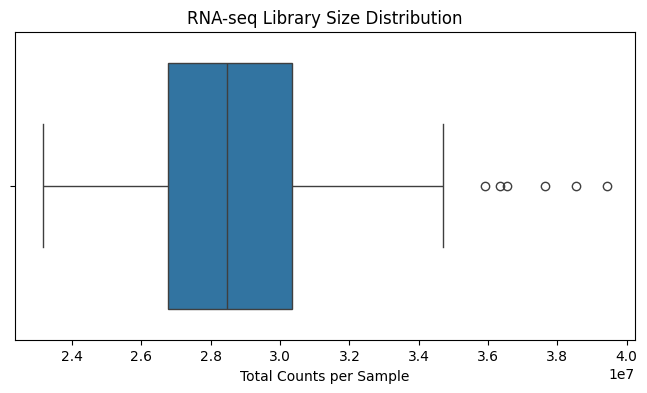

In [5]:
from matplotlib import axes
plt.figure(figsize=(8, 4))
sns.boxplot(x=bulk_seq.iloc[:,2:].sum(axis=0))
plt.title("RNA-seq Library Size Distribution")
plt.xlabel("Total Counts per Sample")
plt.show()

Interpretation: very textbook sequencing (median ~ 2.9E7, minimum baseline according to the literature around 1-1.5E7); library size distribution looks very uniform. High outliers likely not an issue compared to hypothetical low outliers

##### **Total genes per sample**

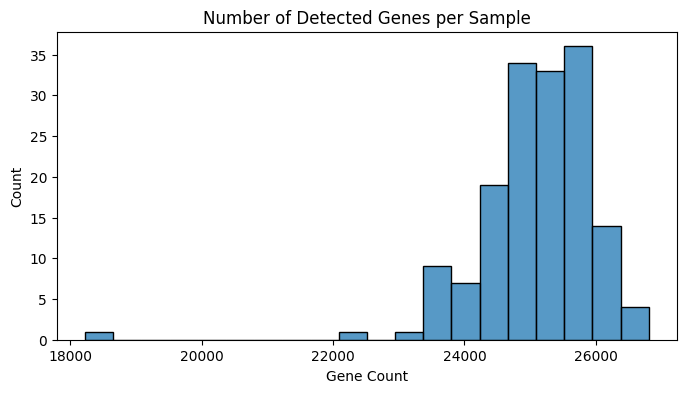

In [ ]:
plt.figure(figsize=(8, 4))
genes_detected = (bulk_seq.iloc[:,2:] > 0).sum(axis=0)
sns.histplot(genes_detected, bins=20)
plt.title("Number of Detected Genes per Sample")
plt.xlabel("Gene Count")
plt.show()

Interpretation: while the vast majority of the samples are normally distributed around ~25000 genes per sample, there are two outliers at 18000 and 22000. 

We should consider the removal of 18000 before moving forward with ML tasks (fewer genes = fewer features compared to the other samples). 


Decision: remove outliers 

### Normalization of Bulk RNA Seq

In [6]:
# CPM Normalization: (counts / column total) * 1,000,000 --> normalizing differences between columns 
rna_cpm = bulk_seq.iloc[:,2:].div(bulk_seq.iloc[:,2:].sum(axis=0), axis=1) * 1_000_000
# atac_cpm = df_atac_raw.div(df_atac_raw.sum(axis=0), axis=1) * 1_000_000

# Log-transform to stabilize variance for ML --> normalizing difference between rows 
rna_log = np.log2(rna_cpm + 1)
# atac_log = np.log2(atac_cpm + 1)

### AnnData Object Creation

#### Creating df of demographics 

In [14]:
df_demographics = df_metadata.copy().iloc[:4]
df_demographics.columns = df_demographics.iloc[0,:].values
df_demographics = df_demographics.drop(index=[0, 1], columns=df_demographics.columns[0])
df_demographics.index = ["age", "sex"]
df_demographics.iloc[0] = df_demographics.iloc[0].astype(str).str.split(" ").str[1].str.strip("'\"")
df_demographics.iloc[1] = df_demographics.iloc[1].astype(str).str.split(" ").str[1].str.strip("'\"")
df_demographics
# df_demographics.columns = df_demographics.iloc[0]


,"""ATAC_CR_027""","""ATAC_CR_028""","""ATAC_CR_029""","""ATAC_CR_030""","""ATAC_CR_031""","""ATAC_CR_032""","""ATAC_CR_034""","""ATAC_CR_035""","""ATAC_CR_036""","""ATAC_CR_037""",...,"""RNA_CR_177""","""RNA_CR_178""","""RNA_CR_179""","""RNA_CR_180""","""RNA_CR_181""","""RNA_CR_182""","""RNA_CR_183""","""RNA_CR_184""","""RNA_CR_185""","""RNA_CR_186"""
age,22,64,58,61,42,45,46,70,66,46,...,31,62,31,65,48,51,30,45,54,44
sex,F,M,F,M,F,M,F,M,F,M,...,M,M,M,M,M,M,M,M,M,F


In [ ]:
bulk_seq.head()

,Geneid,GeneSymbol,RNA_CR_027,RNA_CR_028,RNA_CR_029,RNA_CR_030,RNA_CR_031,RNA_CR_032,RNA_CR_034,RNA_CR_035,...,RNA_CR_177,RNA_CR_178,RNA_CR_179,RNA_CR_180,RNA_CR_181,RNA_CR_182,RNA_CR_183,RNA_CR_184,RNA_CR_185,RNA_CR_186
0,ENSG00000284662,OR4F3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,ENSG00000186827,TNFRSF4,1554,282,436,546,253,460,482,128,...,411,509,303,44,329,589,811,258,1920,1353
2,ENSG00000186891,TNFRSF18,1895,332,885,887,244,710,646,233,...,419,842,510,30,493,808,1138,378,1060,1674
3,ENSG00000160072,ATAD3B,3241,1509,2454,2401,3082,2891,2077,2006,...,2555,2229,2612,177,2605,2775,3331,3458,3768,3887
4,ENSG00000041988,THAP3,432,286,412,405,447,405,321,284,...,412,412,424,200,503,432,607,562,660,644


#### Creating obs, var, and final adata object for bulk rna 

In [ ]:


var_df = pd.DataFrame({
    'Geneid': bulk_seq['Geneid'].values,
    'GeneSymbol': bulk_seq['GeneSymbol'].values
})
var_df.index = bulk_seq['Geneid'].values

# Transpose to match ML format: Rows = Samples, Columns = Genomic Features
numeric_counts = bulk_seq.drop(columns=['Geneid', 'GeneSymbol'])
X_rna = numeric_counts.T
X_rna.columns = var_df.index


##Making the obs df 

df_demographics.columns = df_demographics.columns.str.strip("'\"")
rna_cols = df_demographics.columns[df_demographics.columns.str.startswith("RNA")]
obs_df = df_demographics[rna_cols].copy().T
obs_df.columns = ['age', 'sex']

adata = ad.AnnData(
    X=X_rna.to_numpy().astype('float32'), # ML models prefer float32 over object/int
    obs=obs_df,
    var=var_df
)

adata.obs

array([[   0., 1554., 1895., ...,    0.,    0.,   18.],
       [   0.,  282.,  332., ...,    0.,    0.,    0.],
       [   0.,  436.,  885., ...,    0.,    0.,    0.],
       ...,
       [   0.,  258.,  378., ...,    0.,    0.,    8.],
       [   0., 1920., 1060., ...,    0.,    0.,    0.],
       [   0., 1353., 1674., ...,    0.,    0.,    0.]], dtype=float32)

In [38]:
adata.var

,Geneid,GeneSymbol
ENSG00000284662,ENSG00000284662,OR4F3
ENSG00000186827,ENSG00000186827,TNFRSF4
ENSG00000186891,ENSG00000186891,TNFRSF18
ENSG00000160072,ENSG00000160072,ATAD3B
ENSG00000041988,ENSG00000041988,THAP3
...,...,...
ENSG00000271254,ENSG00000271254,LOC102724250
ENSG00000275987,ENSG00000275987,NaN
ENSG00000268674,ENSG00000268674,NaN
ENSG00000277475,ENSG00000277475,NaN


CPM works at 10^6 while CP10K in Scanpy works at 10^4

## Bulk ATAC Data Processing and AnnData obj creation

### Loading in bulk ATAC seq data

In [30]:
atac_seq = pd.read_csv("/Users/marikaclark/Downloads/GSE193140_atac_counts_qval_0.05.txt", sep = " ")
atac_seq.head()

,chr,start,end,CR_027_1,CR_027_2,CR_028_2,CR_029_1,CR_030_1,CR_031_1,CR_032_1,...,CR_177_1,CR_178_1,CR_179_1,CR_180_1,CR_181_1,CR_182_1,CR_183_1,CR_184_1,CR_185_1,CR_186_1
0,chr1,817225,817615,84,71,138,107,93,81,56,...,70,40,24,51,49,62,20,78,19,41
1,chr1,826662,828151,1004,1039,1277,1379,1136,1375,1111,...,1028,408,221,485,509,596,206,830,240,457
2,chr1,858007,858218,45,61,52,44,36,43,38,...,36,16,14,37,14,34,10,63,19,25
3,chr1,869633,870218,293,300,320,292,194,451,329,...,306,84,66,140,149,179,70,253,109,125
4,chr1,904227,905574,485,569,538,451,368,712,559,...,393,186,124,245,248,283,74,407,135,200


Explanatin of ATAC-seq data layout: 
- first three columns: the genomic coordinates of each open chromatin region (Peak Range) based on reference genome 
- all columns to the right: number of reads/counts for each given chromatin region 

***Need to check why some samples have replicates/duplicates but others don't***
---> in the code below, I average replicates but we can always change this 

### Creating simplified ATAC df for adata obj 
- Combining first 3 columns into the index 
- Averaging replicate samples 

In [ ]:
peak_ids = (
    atac_seq['chr'].astype(str) + "_" + 
    atac_seq['start'].astype(str) + "_" + 
    atac_seq['end'].astype(str)
)
df_atac_numeric = atac_seq.drop(columns=['chr', 'start', 'end'])
df_atac_numeric.index = peak_ids
sample_roots = df_atac_numeric.columns.str.rsplit('_', n=1).str[0]
df_atac_consolidated = df_atac_numeric.groupby(sample_roots, axis=1).mean()
df_atac_consolidated.columns = "RNA_" + df_atac_consolidated.columns

print("--- Replicates Combined ---")
print(f"Original shape: {df_atac_numeric.shape}")
print(f"Consolidated shape: {df_atac_consolidated.shape}")


<positron-console-cell-31>:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.


--- Replicates Combined ---
Original shape: (42557, 163)
Consolidated shape: (42557, 157)


### Bulk ATAC Seq QC: 

In [34]:
# Assuming df_atac_raw columns are your sample IDs after dropping any coordinate text columns
# Calculate matrix diagnostics
atac_depths = df_atac_consolidated.sum(axis=0)
sparsity_per_sample = (df_atac_consolidated == 0).mean(axis=0) * 100
peaks_active = (df_atac_consolidated > 5).sum(axis=0)

# Print a quick summary text report for your meeting notes
print("--- ATAC Matrix QC Summary ---")
print(f"Median Depth per Sample: {atac_depths.median():,.0f}")
print(f"Average Sparsity Rate:   {sparsity_per_sample.mean():.2f}%")
print(f"Median Active Peaks:     {peaks_active.median():,.0f}")

# Quick outlier scan: Find samples > 3 standard deviations away from the median active peaks
cutoff_low = peaks_active.median() - (3 * peaks_active.std())
failed_atac_samples = peaks_active[peaks_active < cutoff_low].index.tolist()
print(f"\nPotential low-complexity ATAC outliers to drop: {failed_atac_samples}")

--- ATAC Matrix QC Summary ---
Median Depth per Sample: 11,060,524
Average Sparsity Rate:   0.29%
Median Active Peaks:     42,509

Potential low-complexity ATAC outliers to drop: ['RNA_CR_132', 'RNA_CR_141', 'RNA_CR_148']


*Investigate why RNA prefix present*

##### **Interpretation:**
- **Average Sparsity Rate:**   0.29% --> because sparsity is normally very high (40% to 70%), during preprocessing, the bioinformatician likely pre-filtered the genome to only include high-confidence master peak regions --> no worry about zero-inflated matrix
- **Median active peaks:** our ML feature count, an average patient has 42,509 specific genomic intervals that are actively open and functioning. 
- **Potential low-complexity ATAC outliers to drop:** ['RNA_CR_132', 'RNA_CR_141', 'RNA_CR_148'] --> library complexity much lower than rest of the cohort --> proportion of sequenced fragments that successfully mapped within your designated peak features is abnormally low compared to the rest of the cohort.



### ATAC Data Normalization 

### ATAC adata object creation 

### Obtaining Sample Overlap

In [ ]:
samples_rna <- 

## Checking sparsity of Bulk RNA Seq Data 

In [ ]:
zero_count = (bulk_seq == 0).sum().sum()
#bulk_seq == 0 --> makes matrix of booleans 
#first .sum() --> first one sums across the columns --> collapses it into one column 
#second .sum() --> sums down that singular column --> collapses to one value 
sparsity_proportion = zero_count/(bulk_seq.size)
sparsity_proportion
#.size --> attribute that gives you the size of the matrix 

np.float64(0.5790349736211189)

In [ ]:
atac_seq_zeros = (atac_seq==0).sum().sum()
atac_seq_zeros

np.int64(0)